In [1]:
import nibabel as nb
import os
import numpy as np
import matplotlib.pyplot as plt
import globals as gl
import nitools as nt
import surfAnalysisPy as surf
from matplotlib.cm import ScalarMappable
import pickle
from Pcm import find_model

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


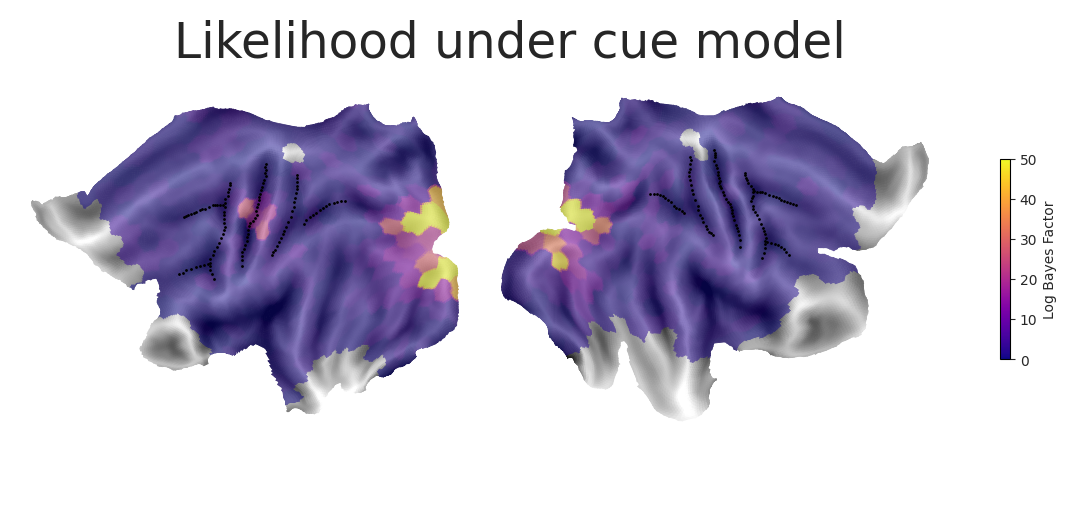

In [40]:
glm = 14
ntessels = 362
experiment = 'smp2'

vmin, vmax = 0, 50

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.pcmDir,
                                      f'ML.Icosahedron{ntessels}.glm{glm}.pcm.plan.dscalar.nii'))

column_names = list(cifti.header.get_axis(0).name)
giftis = nt.split_cifti_to_giftis(cifti, 'func', column_names=column_names)

factor = 'cue'
idx = column_names.index(factor)
idx_null = column_names.index('null')

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

cmap = 'plasma'

for h, H, in enumerate(['L', 'R']):

    g = giftis[h]

    data = nt.get_gifti_data_matrix(g)
    col_names = nt.get_gifti_column_names(g)

    data = data[:, idx] - data[:, idx_null]

    plt.sca(axs[h])
    surf.plot.plotmap(data, f'fs32k_{H}',
                      underlay=None,
                      borders=os.path.join(gl.baseDir, experiment, gl.surfDir, 'fs_LR.32k.L.border'),
                      cscale=[vmin, vmax],
                      cmap=cmap,
                      underscale=[-1.5, 1],
                      alpha=.5,
                      new_figure=False,
                      colorbar=False,
                      # frame=[xlim[Hem][0], xlim[Hem][1], ylim[Hem][0], ylim[Hem][1]]
    )

    # axs[h].set_title(f'hemisphere: {H}')

fig.suptitle(f'Likelihood under {factor} model', fontsize=35)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0, hspace=0)

# make colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=[axs[0], axs[1]], orientation='vertical', fraction=0.01)
cbar.outline.set_edgecolor('k')
cbar.set_label('Log Bayes Factor')

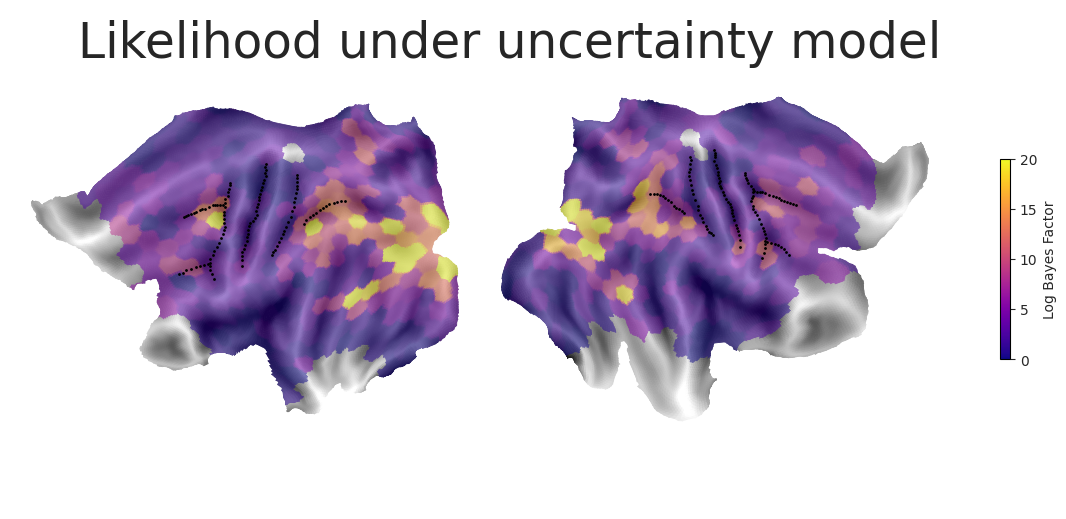

In [41]:
glm = 14
ntessels = 362
experiment = 'smp2'

vmin, vmax = 0, 20

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.pcmDir,
                                      f'ML.Icosahedron{ntessels}.glm{glm}.pcm.plan.dscalar.nii'))

column_names = list(cifti.header.get_axis(0).name)
giftis = nt.split_cifti_to_giftis(cifti, 'func', column_names=column_names)

factor = 'uncertainty'
idx = column_names.index(factor)
idx_null = column_names.index('null')

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

cmap = 'plasma'

for h, H, in enumerate(['L', 'R']):

    g = giftis[h]

    data = nt.get_gifti_data_matrix(g)
    col_names = nt.get_gifti_column_names(g)

    data = data[:, idx] - data[:, idx_null]

    plt.sca(axs[h])
    surf.plot.plotmap(data, f'fs32k_{H}',
                      underlay=None,
                      borders=os.path.join(gl.baseDir, experiment, gl.surfDir, 'fs_LR.32k.L.border'),
                      cscale=[vmin, vmax],
                      cmap=cmap,
                      underscale=[-1.5, 1],
                      alpha=.5,
                      new_figure=False,
                      colorbar=False,
                      # frame=[xlim[Hem][0], xlim[Hem][1], ylim[Hem][0], ylim[Hem][1]]
    )

    # axs[h].set_title(f'hemisphere: {H}')

fig.suptitle(f'Likelihood under {factor} model', fontsize=35)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0, hspace=0)

# make colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=[axs[0], axs[1]], orientation='vertical', fraction=0.01)
cbar.outline.set_edgecolor('k')
cbar.set_label('Log Bayes Factor')

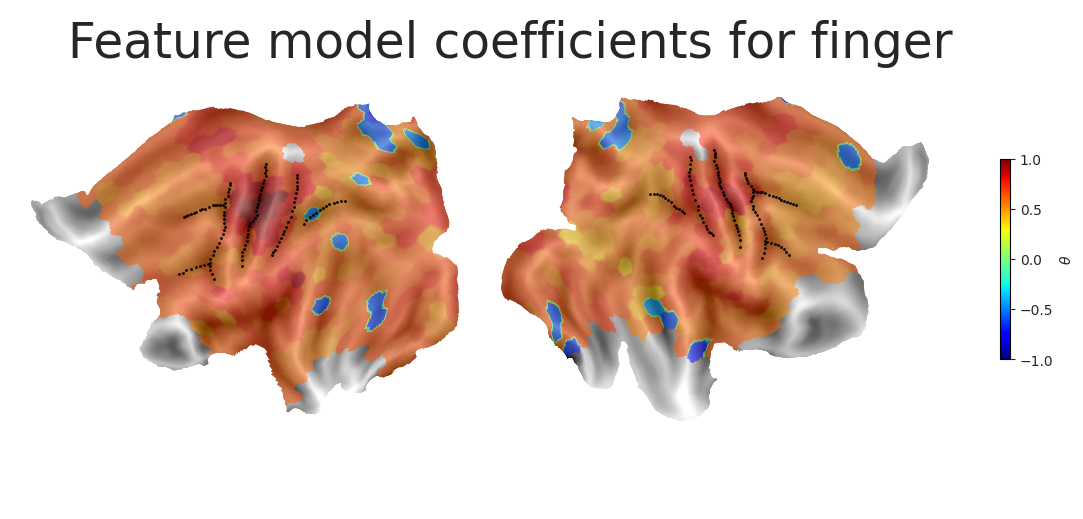

In [32]:
glm = 12
ntessels = 362
experiment = 'smp2'

vmin, vmax = -1, 1

column_names = ['finger','cue', 'uncertainty', 'surprise', 'finger*cue']
factor = 'finger'
idx = column_names.index(factor)

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.pcmDir,
                                      f'theta_feature.Icosahedron{ntessels}.glm{glm}.pcm.exec.dscalar.nii'))

giftis = nt.split_cifti_to_giftis(cifti, 'func', column_names=column_names)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

cmap = 'jet'

for h, H, in enumerate(['L', 'R']):

    g = giftis[h]

    data = nt.get_gifti_data_matrix(g)
    norm = np.linalg.norm(data, axis=1)
    data /= norm[:, None]
    col_names = nt.get_gifti_column_names(g)

    plt.sca(axs[h])
    surf.plot.plotmap(data[:, idx], f'fs32k_{H}',
                          underlay=None,
                          borders=os.path.join(gl.baseDir, experiment, gl.surfDir, 'fs_LR.32k.L.border'),
                          cscale=[vmin, vmax],
                          cmap=cmap,
                          underscale=[-1.5, 1],
                          alpha=.5,
                          new_figure=False,
                          colorbar=False,
                          # frame=[xlim[Hem][0], xlim[Hem][1], ylim[Hem][0], ylim[Hem][1]]
    )
    # axs[h].set_title(f'hemisphere: {H}')

fig.suptitle(f'Feature model coefficients for {factor}', fontsize=35)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0, hspace=0)

# make colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=[axs[0], axs[1]], orientation='vertical', fraction=0.01,)
cbar.outline.set_edgecolor("k")
cbar.set_label(r"$\theta$")

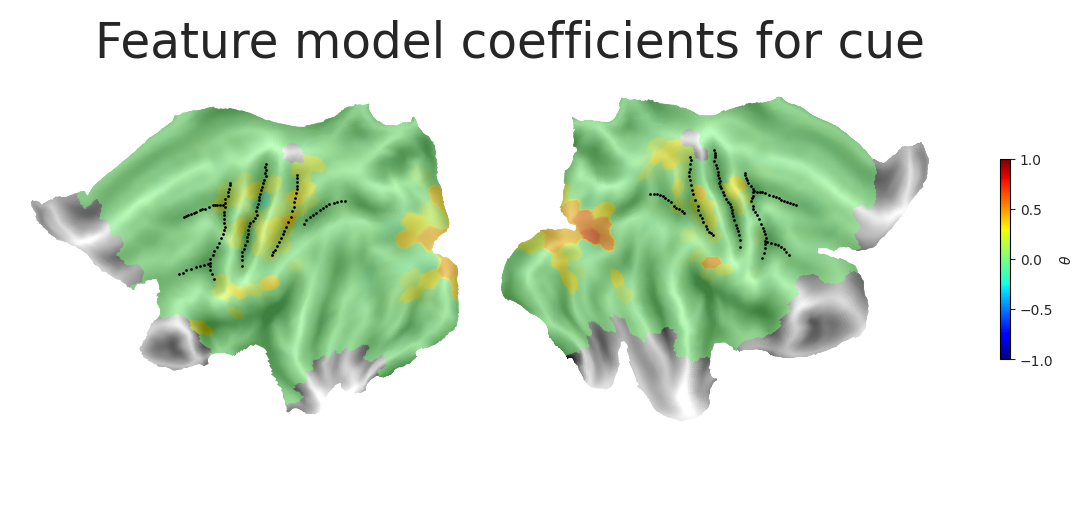

In [33]:
glm = 12
ntessels = 362
experiment = 'smp2'

vmin, vmax = -1, 1

column_names = ['finger','cue', 'uncertainty', 'surprise', 'finger*cue']
factor = 'cue'
idx = column_names.index(factor)

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.pcmDir,
                                      f'theta_feature.Icosahedron{ntessels}.glm{glm}.pcm.exec.dscalar.nii'))

giftis = nt.split_cifti_to_giftis(cifti, 'func', column_names=column_names)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

cmap = 'jet'

for h, H, in enumerate(['L', 'R']):

    g = giftis[h]

    data = nt.get_gifti_data_matrix(g)
    norm = np.linalg.norm(data, axis=1)
    data /= norm[:, None]
    col_names = nt.get_gifti_column_names(g)

    plt.sca(axs[h])
    surf.plot.plotmap(data[:, idx], f'fs32k_{H}',
                          underlay=None,
                          borders=os.path.join(gl.baseDir, experiment, gl.surfDir, 'fs_LR.32k.L.border'),
                          cscale=[vmin, vmax],
                          cmap=cmap,
                          underscale=[-1.5, 1],
                          alpha=.5,
                          new_figure=False,
                          colorbar=False,
                          # frame=[xlim[Hem][0], xlim[Hem][1], ylim[Hem][0], ylim[Hem][1]]
    )
    # axs[h].set_title(f'hemisphere: {H}')

fig.suptitle(f'Feature model coefficients for {factor}', fontsize=35)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0, hspace=0)

# make colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=[axs[0], axs[1]], orientation='vertical', fraction=0.01,)
cbar.outline.set_edgecolor("k")
cbar.set_label(r"$\theta$")

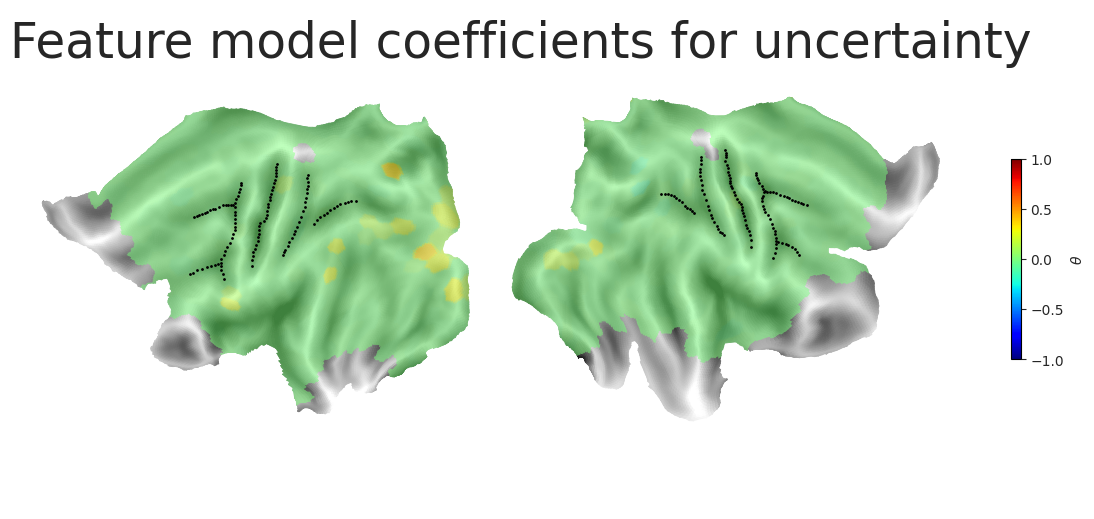

In [34]:
glm = 12
ntessels = 362
experiment = 'smp2'

vmin, vmax = -1, 1

column_names = ['finger','cue', 'uncertainty', 'surprise', 'finger*cue']
factor = 'uncertainty'
idx = column_names.index(factor)

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.pcmDir,
                                      f'theta_feature.Icosahedron{ntessels}.glm{glm}.pcm.exec.dscalar.nii'))

giftis = nt.split_cifti_to_giftis(cifti, 'func', column_names=column_names)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

cmap = 'jet'

for h, H, in enumerate(['L', 'R']):

    g = giftis[h]

    data = nt.get_gifti_data_matrix(g)
    norm = np.linalg.norm(data, axis=1)
    data /= norm[:, None]
    col_names = nt.get_gifti_column_names(g)

    plt.sca(axs[h])
    surf.plot.plotmap(data[:, idx], f'fs32k_{H}',
                          underlay=None,
                          borders=os.path.join(gl.baseDir, experiment, gl.surfDir, 'fs_LR.32k.L.border'),
                          cscale=[vmin, vmax],
                          cmap=cmap,
                          underscale=[-1.5, 1],
                          alpha=.5,
                          new_figure=False,
                          colorbar=False,
                          # frame=[xlim[Hem][0], xlim[Hem][1], ylim[Hem][0], ylim[Hem][1]]
    )
    # axs[h].set_title(f'hemisphere: {H}')

fig.suptitle(f'Feature model coefficients for {factor}', fontsize=35)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0, hspace=0)

# make colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=[axs[0], axs[1]], orientation='vertical', fraction=0.01,)
cbar.outline.set_edgecolor("k")
cbar.set_label(r"$\theta$")

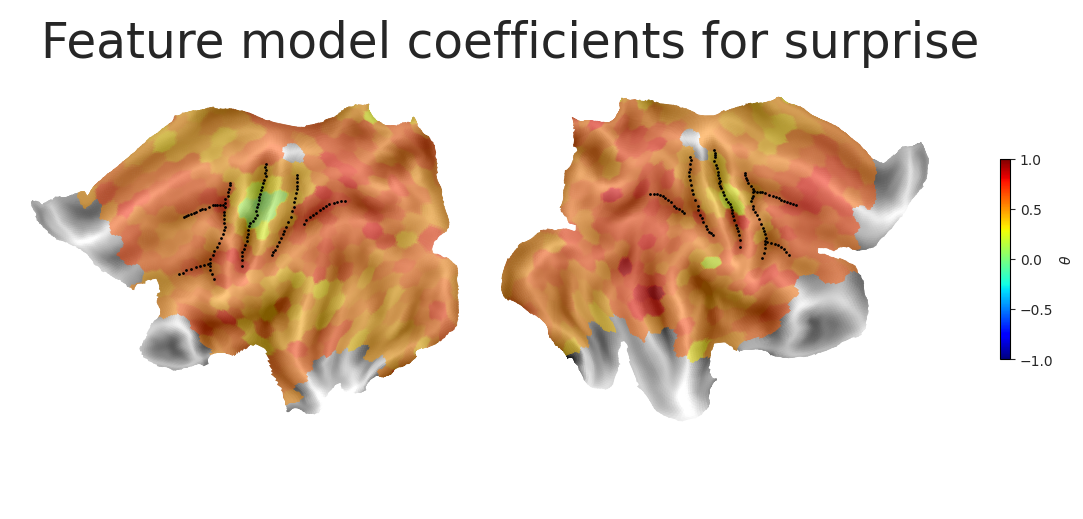

In [35]:
glm = 12
ntessels = 362
experiment = 'smp2'

vmin, vmax = -1, 1

column_names = ['finger','cue', 'uncertainty', 'surprise', 'finger*cue']
factor = 'surprise'
idx = column_names.index(factor)

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.pcmDir,
                                      f'theta_feature.Icosahedron{ntessels}.glm{glm}.pcm.exec.dscalar.nii'))

giftis = nt.split_cifti_to_giftis(cifti, 'func', column_names=column_names)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

cmap = 'jet'

for h, H, in enumerate(['L', 'R']):

    g = giftis[h]

    data = nt.get_gifti_data_matrix(g)
    norm = np.linalg.norm(data, axis=1)
    data /= norm[:, None]
    col_names = nt.get_gifti_column_names(g)

    plt.sca(axs[h])
    surf.plot.plotmap(data[:, idx], f'fs32k_{H}',
                          underlay=None,
                          borders=os.path.join(gl.baseDir, experiment, gl.surfDir, 'fs_LR.32k.L.border'),
                          cscale=[vmin, vmax],
                          cmap=cmap,
                          underscale=[-1.5, 1],
                          alpha=.5,
                          new_figure=False,
                          colorbar=False,
                          # frame=[xlim[Hem][0], xlim[Hem][1], ylim[Hem][0], ylim[Hem][1]]
    )
    # axs[h].set_title(f'hemisphere: {H}')

fig.suptitle(f'Feature model coefficients for {factor}', fontsize=35)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0, hspace=0)

# make colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=[axs[0], axs[1]], orientation='vertical', fraction=0.01,)
cbar.outline.set_edgecolor("k")
cbar.set_label(r"$\theta$")

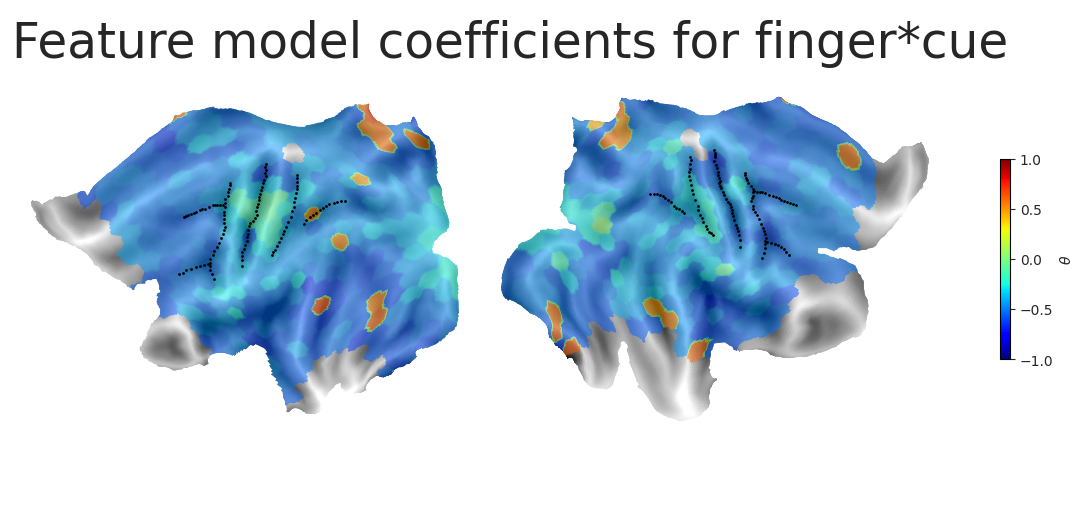

In [36]:
glm = 12
ntessels = 362
experiment = 'smp2'

vmin, vmax = -1, 1

column_names = ['finger','cue', 'uncertainty', 'surprise', 'finger*cue']
factor = 'finger*cue'
idx = column_names.index(factor)

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.pcmDir,
                                      f'theta_feature.Icosahedron{ntessels}.glm{glm}.pcm.exec.dscalar.nii'))

giftis = nt.split_cifti_to_giftis(cifti, 'func', column_names=column_names)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

cmap = 'jet'

for h, H, in enumerate(['L', 'R']):

    g = giftis[h]

    data = nt.get_gifti_data_matrix(g)
    norm = np.linalg.norm(data, axis=1)
    data /= norm[:, None]
    col_names = nt.get_gifti_column_names(g)

    plt.sca(axs[h])
    surf.plot.plotmap(data[:, idx], f'fs32k_{H}',
                          underlay=None,
                          borders=os.path.join(gl.baseDir, experiment, gl.surfDir, 'fs_LR.32k.L.border'),
                          cscale=[vmin, vmax],
                          cmap=cmap,
                          underscale=[-1.5, 1],
                          alpha=.5,
                          new_figure=False,
                          colorbar=False,
                          # frame=[xlim[Hem][0], xlim[Hem][1], ylim[Hem][0], ylim[Hem][1]]
    )
    # axs[h].set_title(f'hemisphere: {H}')

fig.suptitle(f'Feature model coefficients for {factor}', fontsize=35)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0, hspace=0)

# make colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=[axs[0], axs[1]], orientation='vertical', fraction=0.01,)
cbar.outline.set_edgecolor("k")
cbar.set_label(r"$\theta$")